In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("dataset.csv")
display(df)

,Timestamp,Date,Time_of_Day_Hour,Day_of_Week,Month,Is_Weekend,Students_Present,Ambient_Temperature_C,HVAC_Load_kW,Lighting_Load_kW,Computer_Load_kW,Lab_Equipment_Load_kW,Energy_Usage_kWh
0,2024-01-01 00:00,2024-01-01,0,0,1,0,38,10.56,55.95,22.12,2.17,0,62.73
1,2024-01-01 01:00,2024-01-01,1,0,1,0,28,9.50,62.25,16.94,0.00,0,67.76
2,2024-01-01 02:00,2024-01-01,2,0,1,0,14,11.60,51.07,2.12,0.00,0,46.69
3,2024-01-01 03:00,2024-01-01,3,0,1,0,7,9.27,71.19,0.19,0.00,0,61.69
4,2024-01-01 04:00,2024-01-01,4,0,1,0,20,12.69,51.24,0.00,10.24,0,55.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2024-07-27 03:00,2024-07-27,3,5,7,1,11,25.05,16.78,9.78,2.36,0,26.14
4996,2024-07-27 04:00,2024-07-27,4,5,7,1,0,25.23,13.11,2.77,12.34,0,18.59
4997,2024-07-27 05:00,2024-07-27,5,5,7,1,39,27.01,29.03,18.32,5.96,0,34.97
4998,2024-07-27 06:00,2024-07-27,6,5,7,1,10,26.08,20.76,1.75,0.00,0,21.70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              5000 non-null   object 
 1   Date                   5000 non-null   object 
 2   Time_of_Day_Hour       5000 non-null   int64  
 3   Day_of_Week            5000 non-null   int64  
 4   Month                  5000 non-null   int64  
 5   Is_Weekend             5000 non-null   int64  
 6   Students_Present       5000 non-null   int64  
 7   Ambient_Temperature_C  5000 non-null   float64
 8   HVAC_Load_kW           5000 non-null   float64
 9   Lighting_Load_kW       5000 non-null   float64
 10  Computer_Load_kW       5000 non-null   float64
 11  Lab_Equipment_Load_kW  5000 non-null   int64  
 12  Energy_Usage_kWh       5000 non-null   float64
dtypes: float64(5), int64(6), object(2)
memory usage: 507.9+ KB


In [4]:
df['Lab_Equipment_Load_kW'] = df['Lab_Equipment_Load_kW'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              5000 non-null   object 
 1   Date                   5000 non-null   object 
 2   Time_of_Day_Hour       5000 non-null   int64  
 3   Day_of_Week            5000 non-null   int64  
 4   Month                  5000 non-null   int64  
 5   Is_Weekend             5000 non-null   int64  
 6   Students_Present       5000 non-null   int64  
 7   Ambient_Temperature_C  5000 non-null   float64
 8   HVAC_Load_kW           5000 non-null   float64
 9   Lighting_Load_kW       5000 non-null   float64
 10  Computer_Load_kW       5000 non-null   float64
 11  Lab_Equipment_Load_kW  5000 non-null   float64
 12  Energy_Usage_kWh       5000 non-null   float64
dtypes: float64(6), int64(5), object(2)
memory usage: 507.9+ KB


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              5000 non-null   datetime64[ns]
 1   Date                   5000 non-null   datetime64[ns]
 2   Time_of_Day_Hour       5000 non-null   int64         
 3   Day_of_Week            5000 non-null   int64         
 4   Month                  5000 non-null   int64         
 5   Is_Weekend             5000 non-null   int64         
 6   Students_Present       5000 non-null   int64         
 7   Ambient_Temperature_C  5000 non-null   float64       
 8   HVAC_Load_kW           5000 non-null   float64       
 9   Lighting_Load_kW       5000 non-null   float64       
 10  Computer_Load_kW       5000 non-null   float64       
 11  Lab_Equipment_Load_kW  5000 non-null   float64       
 12  Energy_Usage_kWh       5000 non-null   float64       
dtypes: 

In [7]:
print("The number of missing values in each column are:\n",df.isnull().sum())

The number of missing values in each column are:
 Timestamp                0
Date                     0
Time_of_Day_Hour         0
Day_of_Week              0
Month                    0
Is_Weekend               0
Students_Present         0
Ambient_Temperature_C    0
HVAC_Load_kW             0
Lighting_Load_kW         0
Computer_Load_kW         0
Lab_Equipment_Load_kW    0
Energy_Usage_kWh         0
dtype: int64


In [8]:
dup= df.duplicated().sum()
if dup==0:
    print('There are no duplicate rows in the dataset')
else:
    print('There are duplicate rows in the dataset')
    

There are no duplicate rows in the dataset


In [9]:
cols = ['Energy_Usage_kWh', 'HVAC_Load_kW', 'Computer_Load_kW']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(col, ":", len(outliers), "outliers")

Energy_Usage_kWh : 1 outliers
HVAC_Load_kW : 1 outliers
Computer_Load_kW : 19 outliers


In [10]:
#The outliers weren't removed as they were valid, rare events not any data errors. Due to this reason all the outliers were kept in th efinal datatset.


In [11]:

print("Cleaned dataset shape:", df.shape)
print(df.head())


df.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset saved!")

Cleaned dataset shape: (5000, 13)
            Timestamp       Date  Time_of_Day_Hour  Day_of_Week  Month  \
0 2024-01-01 00:00:00 2024-01-01                 0            0      1   
1 2024-01-01 01:00:00 2024-01-01                 1            0      1   
2 2024-01-01 02:00:00 2024-01-01                 2            0      1   
3 2024-01-01 03:00:00 2024-01-01                 3            0      1   
4 2024-01-01 04:00:00 2024-01-01                 4            0      1   

   Is_Weekend  Students_Present  Ambient_Temperature_C  HVAC_Load_kW  \
0           0                38                  10.56         55.95   
1           0                28                   9.50         62.25   
2           0                14                  11.60         51.07   
3           0                 7                   9.27         71.19   
4           0                20                  12.69         51.24   

   Lighting_Load_kW  Computer_Load_kW  Lab_Equipment_Load_kW  Energy_Usage_kWh  
0      

Cleaned dataset saved!


In [12]:
import matplotlib.pyplot as plt
X = df.drop(columns=['Timestamp', 'Date', 'Energy_Usage_kWh'])
y = df['Energy_Usage_kWh']


corr = X.corrwith(y).abs().sort_values(ascending=False)

print("Correlation of each feature with Energy Usage:")
print(corr)

X_final =X[corr[corr > 0.1].index.tolist()]

print("\nFeatures kept   :", list(X_final.columns))
print("Features dropped:", list(corr[corr <= 0.1].index))


Correlation of each feature with Energy Usage:
Students_Present         0.923095
Computer_Load_kW         0.913527
Lighting_Load_kW         0.879257
HVAC_Load_kW             0.732391
Lab_Equipment_Load_kW    0.623280
Is_Weekend               0.448101
Day_of_Week              0.355250
Time_of_Day_Hour         0.166775
Ambient_Temperature_C    0.141010
Month                    0.063323
dtype: float64

Features kept   : ['Students_Present', 'Computer_Load_kW', 'Lighting_Load_kW', 'HVAC_Load_kW', 'Lab_Equipment_Load_kW', 'Is_Weekend', 'Day_of_Week', 'Time_of_Day_Hour', 'Ambient_Temperature_C']
Features dropped: ['Month']


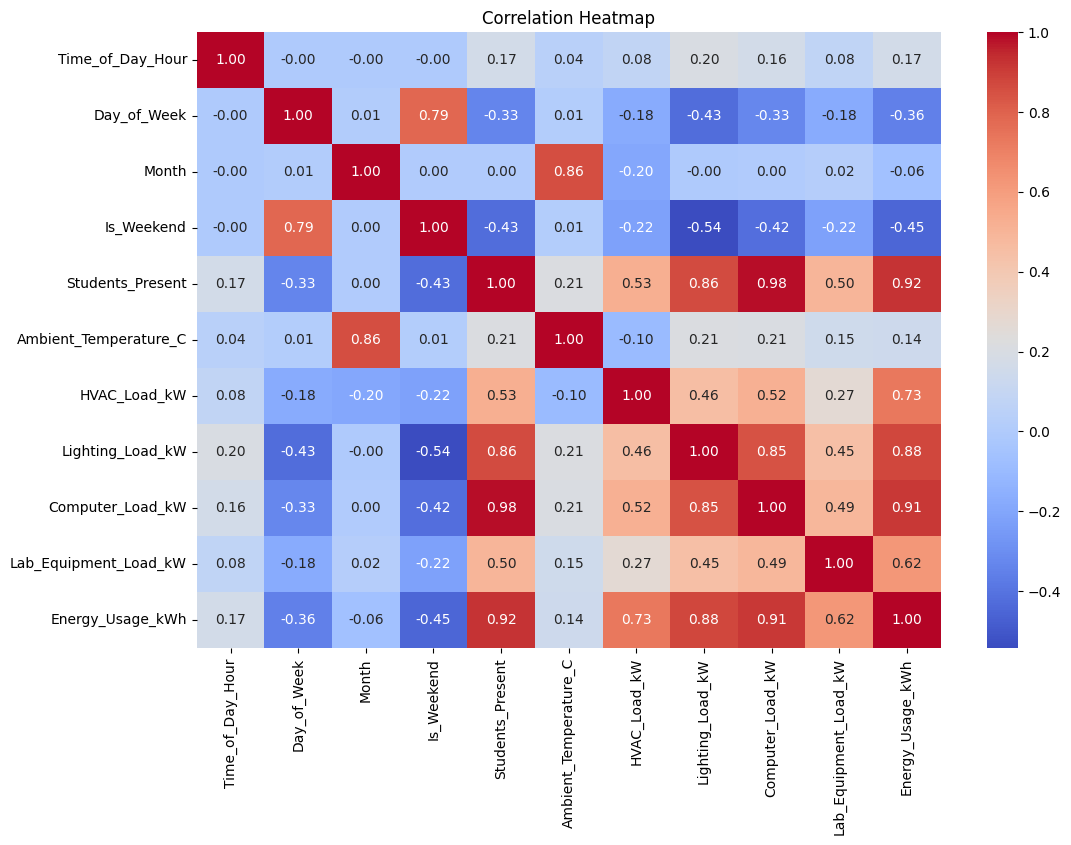

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

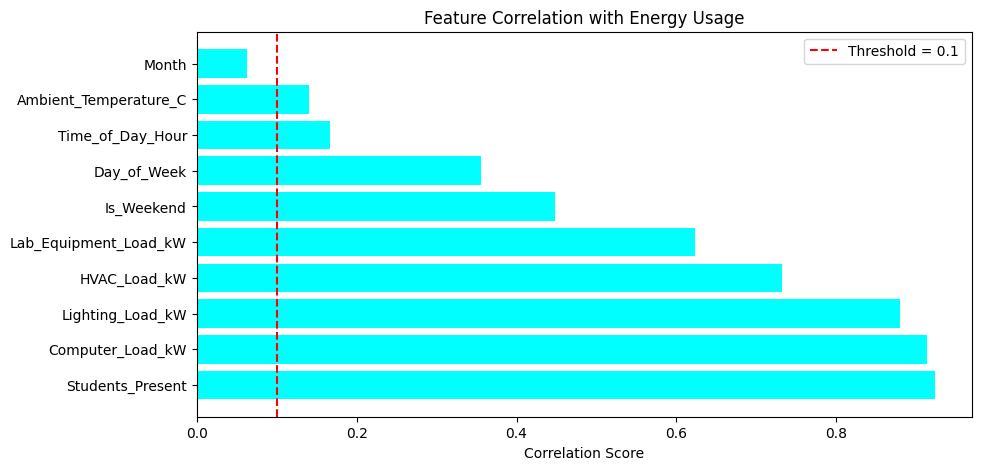

In [14]:
plt.figure(figsize=(10, 5))

plt.barh(corr.index, corr.values, color='cyan')

plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold = 0.1')

plt.title('Feature Correlation with Energy Usage')
plt.xlabel('Correlation Score')
plt.legend()
plt.show()

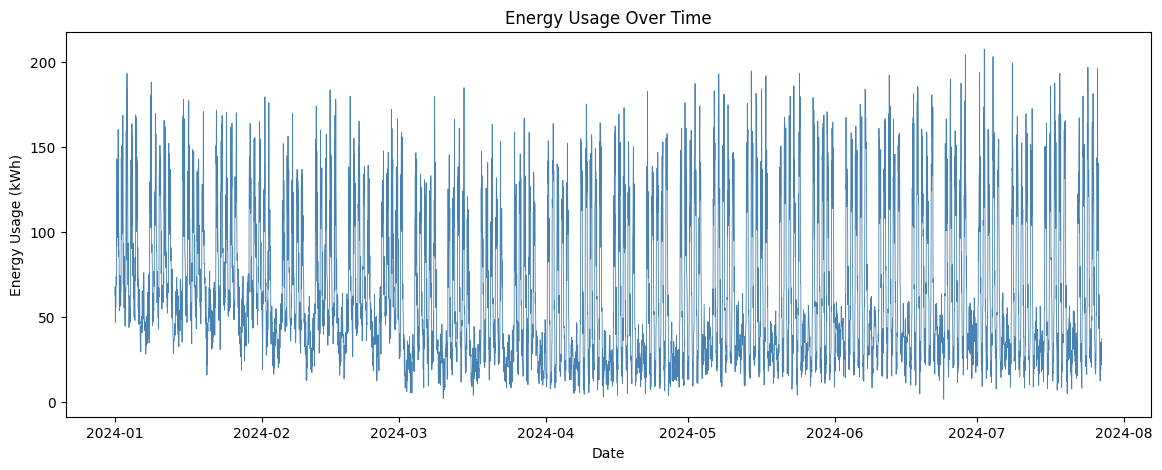

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df['Timestamp'], df['Energy_Usage_kWh'], color='steelblue', linewidth=0.6)
plt.title('Energy Usage Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Usage (kWh)')
plt.show()

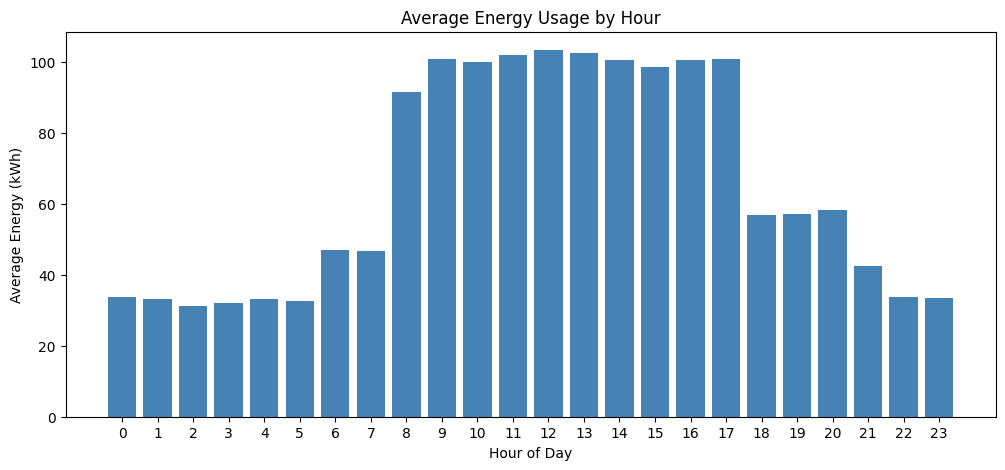

In [16]:
hourly = df.groupby('Time_of_Day_Hour')['Energy_Usage_kWh'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color='steelblue')
plt.title('Average Energy Usage by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (kWh)')
plt.xticks(range(0, 24))
plt.show()

C:\Users\Vinamra\AppData\Local\Temp\ipykernel_22560\2310533241.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday, weekend], labels=['Weekday', 'Weekend'])


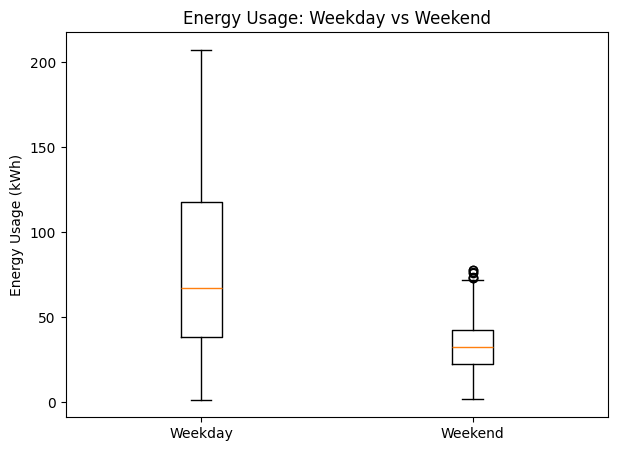

In [17]:
weekday = df[df['Is_Weekend'] == 0]['Energy_Usage_kWh']
weekend = df[df['Is_Weekend'] == 1]['Energy_Usage_kWh']

plt.figure(figsize=(7, 5))
plt.boxplot([weekday, weekend], labels=['Weekday', 'Weekend'])
plt.title('Energy Usage: Weekday vs Weekend')
plt.ylabel('Energy Usage (kWh)')
plt.show()

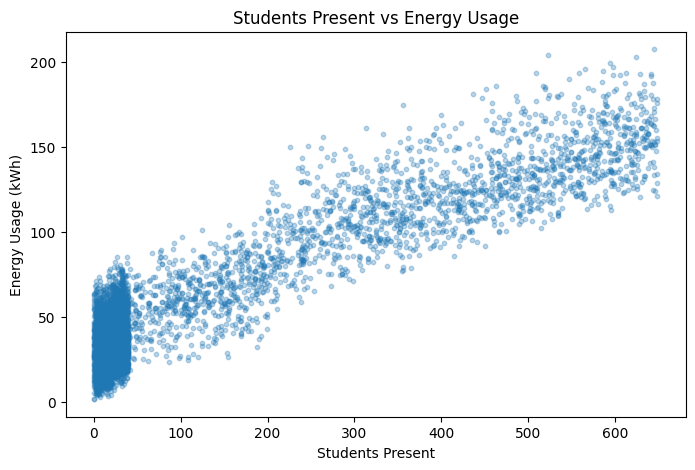

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Students_Present'], df['Energy_Usage_kWh'], alpha=0.3, s=10)
plt.title('Students Present vs Energy Usage')
plt.xlabel('Students Present')
plt.ylabel('Energy Usage (kWh)')
plt.show()

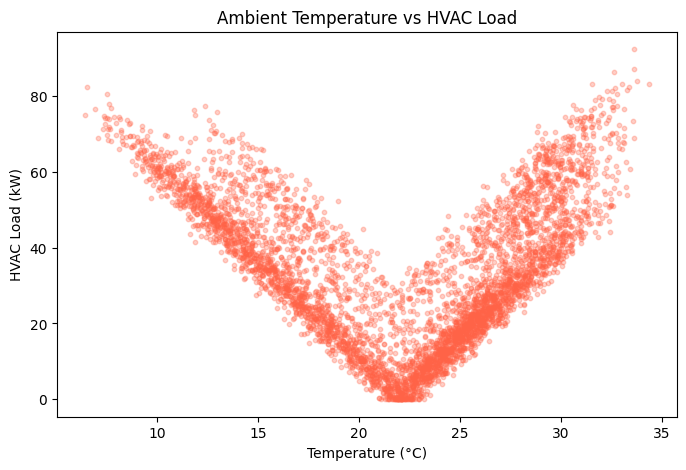

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Ambient_Temperature_C'], df['HVAC_Load_kW'], alpha=0.3, s=10, color='tomato')
plt.title('Ambient Temperature vs HVAC Load')
plt.xlabel('Temperature (°C)')
plt.ylabel('HVAC Load (kW)')
plt.show()